# Tugas 3: Generasi Judul Berita dengan Encoder-Decoder dan Transformer
- Penulis: Ach. Nur Aqil Wahid
- Deskripsi singkat: Membangun tiga arsitektur model generatif untuk membuat judul dari artikel berita.

# Import Library

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer

# Load & Persiapan Dataset

In [2]:
# Tambahkan path project root ke Python path
project_root = os.path.abspath('..')  # karena notebook ada di dalam notebooks/
sys.path.append(project_root)

print("✔️ Path ditambahkan:", project_root)

✔️ Path ditambahkan: c:\Users\aqilw\UGM\2. Semester 2\Pemrosesan Bahasa Alami Lanjut (PBAL)\3. Tugas Generasi Judul Berita\Generasi-Judul-Berita


In [3]:
file_path = r"C:\Users\aqilw\UGM\2. Semester 2\Pemrosesan Bahasa Alami Lanjut (PBAL)\3. Tugas Generasi Judul Berita\Generasi-Judul-Berita\data\newsapi_articles.json"

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

raw_inputs = [item['content'] for item in data if item['content'] and item['title']]
raw_targets = [item['title'] for item in data if item['content'] and item['title']]

print(f"Jumlah data: {len(raw_inputs)}")
print(f"Contoh judul: {raw_targets[0]}")

Jumlah data: 735
Contoh judul: Grid-Scale Battery Storage Is Quietly Revolutionizing the Energy System


In [4]:
from utils.preprocessing import (
    clean_text,
    prepare_tokenizer,
    encode_sequences,
    get_train_test_split
)

# Bersihkan teks
inputs = [clean_text(text) for text in raw_inputs]
targets = [f"<start> {clean_text(text)} <end>" for text in raw_targets]

# Tokenisasi
input_tokenizer, target_tokenizer = prepare_tokenizer(inputs, targets)

# Sequence dan padding
input_seq, target_seq = encode_sequences(
    input_tokenizer, target_tokenizer,
    inputs, targets,
    max_len_input=300,
    max_len_target=30
)

# Split
X_train, X_test, y_train, y_test = get_train_test_split(input_seq, target_seq)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 588 | Test size: 147


# Model 1: Encoder-Decoder LSTM

In [5]:
from models.encoder_decoder_lstm import build_lstm_seq2seq_model

# Dapatkan ukuran vocab
input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

model = build_lstm_seq2seq_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    max_input_len=300,
    max_target_len=30
)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 30)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 300, 128)     790528      ['input_1[0][0]']                
                                                                                                  
 embedding_1 (Embedding)        (None, 30, 128)      384640      ['input_2[0][0]']                
                                                                                              

### Decoder Inputs & Outputs

In [6]:
import numpy as np

def create_decoder_data(target_seq):
    decoder_input_data = target_seq[:, :-1]  # semua kecuali token terakhir
    decoder_target_data = target_seq[:, 1:]  # semua kecuali token pertama
    return decoder_input_data, decoder_target_data

decoder_input_train, decoder_target_train = create_decoder_data(y_train)
decoder_input_test, decoder_target_test = create_decoder_data(y_test)

### Build & Compile Model

In [7]:
from models.encoder_decoder_lstm import build_lstm_seq2seq_model

input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

model = build_lstm_seq2seq_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    max_input_len=300,
    max_target_len=29  # karena kita geser 1
)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 input_4 (InputLayer)           [(None, 29)]         0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 300, 128)     790528      ['input_3[0][0]']                
                                                                                                  
 embedding_3 (Embedding)        (None, 29, 128)      384640      ['input_4[0][0]']                
                                                                                            

### Latih Model

In [8]:
history = model.fit(
    [X_train, decoder_input_train],
    np.expand_dims(decoder_target_train, -1),  # karena pakai sparse_categorical_crossentropy
    validation_split=0.1,
    batch_size=16,
    epochs=20
)


Epoch 1/20
34/34 [==============================] - 13s 74ms/step - loss: 4.7581 - accuracy: 0.5388 - val_loss: 3.2529 - val_accuracy: 0.5804
Epoch 2/20
34/34 [==============================] - 1s 44ms/step - loss: 3.2228 - accuracy: 0.5596 - val_loss: 3.2580 - val_accuracy: 0.5850
Epoch 3/20
34/34 [==============================] - 1s 42ms/step - loss: 3.0861 - accuracy: 0.5637 - val_loss: 3.1727 - val_accuracy: 0.5926
Epoch 4/20
34/34 [==============================] - 1s 43ms/step - loss: 2.9160 - accuracy: 0.5781 - val_loss: 3.1210 - val_accuracy: 0.6108
Epoch 5/20
34/34 [==============================] - 1s 43ms/step - loss: 2.9607 - accuracy: 0.5876 - val_loss: 3.1232 - val_accuracy: 0.6178
Epoch 6/20
34/34 [==============================] - 2s 45ms/step - loss: 2.8005 - accuracy: 0.5986 - val_loss: 3.1391 - val_accuracy: 0.6201
Epoch 7/20
34/34 [==============================] - 1s 44ms/step - loss: 2.7571 - accuracy: 0.5987 - val_loss: 3.1532 - val_accuracy: 0.6160
Epoch 8/20
3

### Visualisasi Training Loss & Akurasi

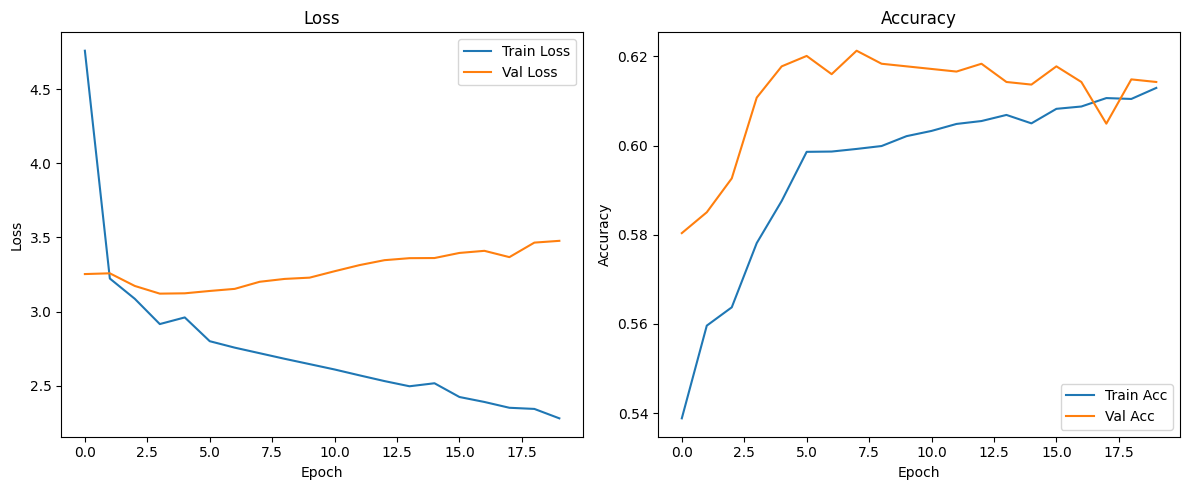

In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Panggil fungsi
plot_training_history(history)


### Fungsi Inference (Generate Judul)

In [10]:
def decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer, decoder_max_len=29):
    reverse_target_word_index = {i: w for w, i in target_tokenizer.word_index.items()}
    decoder_input = np.zeros((1, decoder_max_len))

    output_seq = model.predict([input_seq_single, decoder_input])
    output_tokens = np.argmax(output_seq[0], axis=-1)

    decoded_sentence = []
    for idx in output_tokens:
        word = reverse_target_word_index.get(idx, '')
        if word in ('<end>', ''):
            break
        if word != '<start>':
            decoded_sentence.append(word)
    
    return ' '.join(decoded_sentence)

### Generate Judul & Simpan ke CSV

In [11]:
# Ambil sampel dari test set
num_samples = len(X_test)
generated = []

for i in range(num_samples):    
    input_seq_single = np.expand_dims(X_test[i], axis=0)
    generated_title = decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer)
    original_article = raw_inputs[i]
    actual_title = raw_targets[i]
    
    generated.append({
        'original_article': original_article,
        'actual_title': actual_title,
        'generated_title': generated_title
    })

# Simpan ke CSV
df_generated = pd.DataFrame(generated)
df_generated.to_csv('../outputs/generated_headlines.csv', index=False)

print("✅ Headline berhasil disimpan ke outputs/generated_headlines.csv")


1/1 [==============================] - 0s 42ms/step
✅ Headline berhasil disimpan ke outputs/generated_headlines.csv


-------------------

# Model 2: Encoder-Decoder + Attention

In [12]:
from models.encoder_decoder_attention import build_lstm_attention_model

model_attn = build_lstm_attention_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    max_input_len=300,
    max_target_len=29
)

model_attn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_attn.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 input_6 (InputLayer)           [(None, 29)]         0           []                               
                                                                                                  
 embedding_4 (Embedding)        (None, 300, 128)     790528      ['input_5[0][0]']                
                                                                                                  
 embedding_5 (Embedding)        (None, 29, 128)      384640      ['input_6[0][0]']                
                                                                                            

### Train Model 2

In [13]:
history_attn = model_attn.fit(
    [X_train, decoder_input_train],
    np.expand_dims(decoder_target_train, -1),
    validation_split=0.1,
    batch_size=16,
    epochs=20
)


Epoch 1/20
34/34 [==============================] - 6s 70ms/step - loss: 4.4508 - accuracy: 0.5395 - val_loss: 3.2723 - val_accuracy: 0.5804
Epoch 2/20
34/34 [==============================] - 1s 44ms/step - loss: 3.1730 - accuracy: 0.5622 - val_loss: 3.2571 - val_accuracy: 0.5862
Epoch 3/20
34/34 [==============================] - 2s 47ms/step - loss: 2.9744 - accuracy: 0.5710 - val_loss: 3.1678 - val_accuracy: 0.6078
Epoch 4/20
34/34 [==============================] - 2s 50ms/step - loss: 2.8984 - accuracy: 0.5874 - val_loss: 3.1914 - val_accuracy: 0.6160
Epoch 5/20
34/34 [==============================] - 2s 49ms/step - loss: 2.8332 - accuracy: 0.5967 - val_loss: 3.2205 - val_accuracy: 0.6154
Epoch 6/20
34/34 [==============================] - 2s 48ms/step - loss: 2.7839 - accuracy: 0.5977 - val_loss: 3.2580 - val_accuracy: 0.6189
Epoch 7/20
34/34 [==============================] - 2s 46ms/step - loss: 2.7392 - accuracy: 0.5997 - val_loss: 3.3068 - val_accuracy: 0.6184
Epoch 8/20
34

### Evaluate + Generate Headline

In [14]:
generated_title = decode_sequence(input_seq_single, model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)

1/1 [==============================] - 1s 799ms/step


In [15]:
df_generated.to_csv('../outputs/generated_headlines_attention.csv', index=False)

### Visualisasi Loss dan Akurasi Model 2

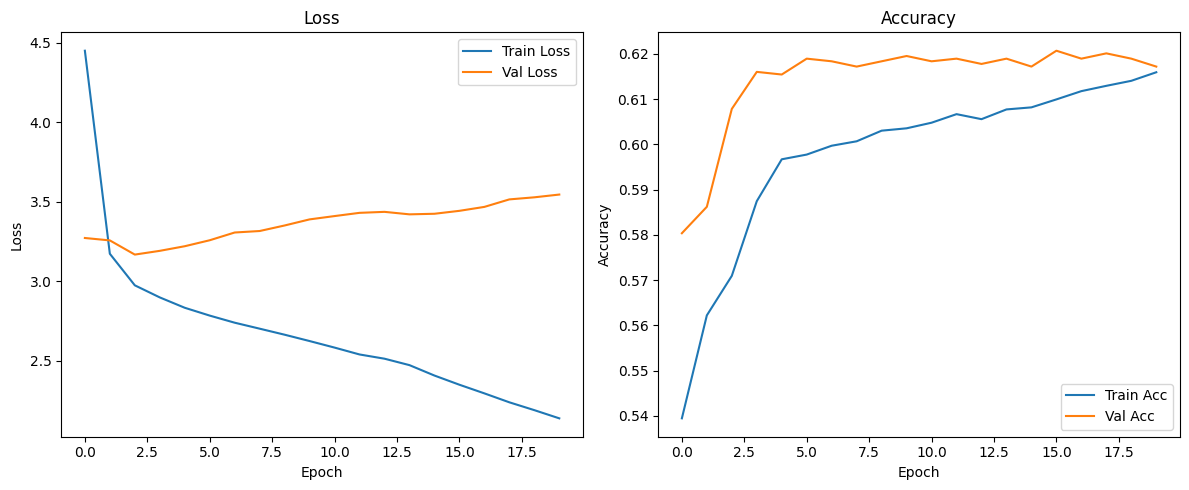

In [16]:
plot_training_history(history_attn)


### Perebandingan dua model dalam satu grafik

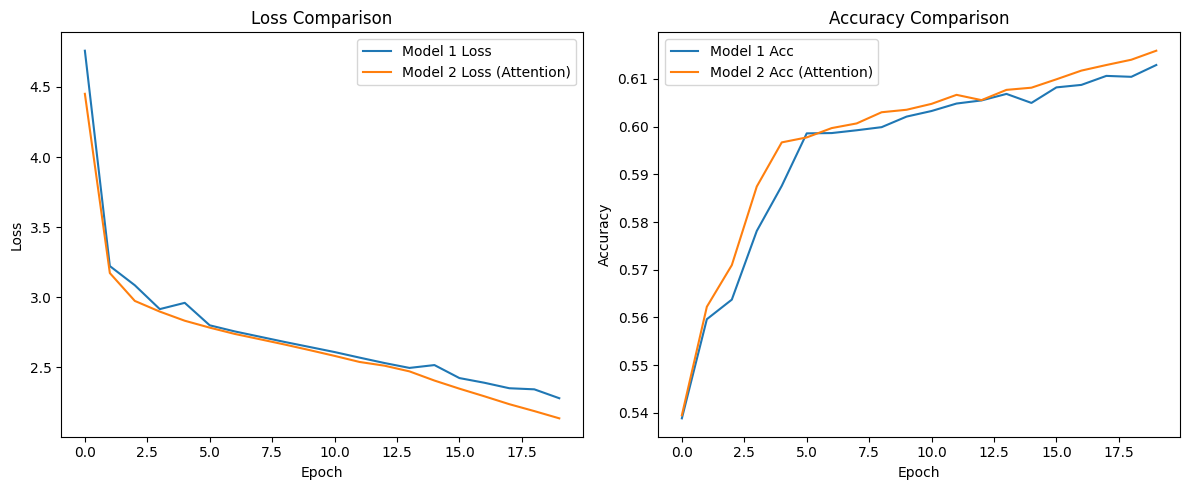

In [17]:
plt.figure(figsize=(12, 5))

# Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Model 1 Loss')
plt.plot(history_attn.history['loss'], label='Model 2 Loss (Attention)')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Model 1 Acc')
plt.plot(history_attn.history['accuracy'], label='Model 2 Acc (Attention)')
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### Evaluasi Kualitatif: Bandingkan Headline

In [18]:
from IPython.display import display, Markdown

for i in range(5):  # ambil 5 sampel untuk analisis
    input_seq_single = np.expand_dims(X_test[i], axis=0)

    gen_title_1 = decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer, decoder_max_len=29)
    gen_title_2 = decode_sequence(input_seq_single, model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)

    display(Markdown(f"""
**Artikel**:
{raw_inputs[i]}

**Judul Asli**:
🟢 {raw_targets[i]}

**Model 1 (tanpa Attention)**:
🔵 {gen_title_1}

**Model 2 (dengan Attention)**:
🟣 {gen_title_2}
---
"""))


1/1 [==============================] - 0s 48ms/step



**Artikel**:
Grid batteries have a halo effect for other power generators too. Most thermal power plantscoal, gas, nuclearprefer to run at a steady pace. Ramping up and down to match demand takes time and costs m… [+4011 chars]

**Judul Asli**:
🟢 Grid-Scale Battery Storage Is Quietly Revolutionizing the Energy System

**Model 1 (tanpa Attention)**:
🔵 the to to end

**Model 2 (dengan Attention)**:
🟣 the is to end end end
---


1/1 [==============================] - 0s 42ms/step



**Artikel**:
Voting for the Peoples Voice Award ends on April 17th, 2025.
Voting for the Peoples Voice Award ends on April 17th, 2025.
The time of year has arrived Webby Award season. For the 29th annual Webby … [+1013 chars]

**Judul Asli**:
🟢 The Verge is nominated for two Webby Awards — help us win them!

**Model 1 (tanpa Attention)**:
🔵 the to to end

**Model 2 (dengan Attention)**:
🟣 the is to end end end
---


1/1 [==============================] - 0s 44ms/step



**Artikel**:
Indian Prime Minister Narendra Modi said he discussed his country's potential to collaborate with the US on "technology and innovation" during a conversation with Elon Musk.
On Friday, Modi shared a… [+1815 chars]

**Judul Asli**:
🟢 PM Modi and Elon Musk talk India-US tech collaboration

**Model 1 (tanpa Attention)**:
🔵 the to to end

**Model 2 (dengan Attention)**:
🟣 the is to end end end
---


1/1 [==============================] - 0s 46ms/step



**Artikel**:
This is a recording of the keynote talk I gave at the Trenton Computer Festival on March 29, 2025. The theme of the festival was Fun With Technology and I talked about how Make and Maker Faire have b… [+26292 chars]

**Judul Asli**:
🟢 Fun With Technology

**Model 1 (tanpa Attention)**:
🔵 the to to end

**Model 2 (dengan Attention)**:
🟣 the is to end end end
---


1/1 [==============================] - 0s 42ms/step



**Artikel**:
The Colorsoft is a far better value at this price, especially if you own a lot of Kindle books. 
The Colorsoft is a far better value at this price, especially if you own a lot of Kindle books. 
Bui… [+1349 chars]

**Judul Asli**:
🟢 The Kindle Colorsoft, Amazon’s first color e-reader, is $55 off

**Model 1 (tanpa Attention)**:
🔵 the to to end

**Model 2 (dengan Attention)**:
🟣 the is to end end end
---


-----------------

# Model 3: Transformer

Menggunakan Custom Transformers karena pytorch saya bentrok dengan Tensorflow

### Positional Encoding Layer

In [19]:
import tensorflow as tf

class PositionalEncoding(tf.keras.layers.Layer):
    def call(self, inputs):
        positions = tf.range(tf.shape(inputs)[1])[:, tf.newaxis]
        return inputs + tf.cast(positions, tf.float32)

### Transformer Block Function

In [20]:
def transformer_block(embed_dim, num_heads, ff_dim):
    inputs = tf.keras.Input(shape=(None, embed_dim))
    attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    attention = tf.keras.layers.Add()([inputs, attention])
    attention = tf.keras.layers.LayerNormalization()(attention)

    ff = tf.keras.layers.Dense(ff_dim, activation="relu")(attention)
    ff = tf.keras.layers.Dense(embed_dim)(ff)
    outputs = tf.keras.layers.Add()([attention, ff])
    outputs = tf.keras.layers.LayerNormalization()(outputs)
    return tf.keras.Model(inputs=inputs, outputs=outputs)


### Model Custom Transformer

In [21]:
embed_dim = 128
num_heads = 4
ff_dim = 512

input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

# Encoder
encoder_inputs = tf.keras.Input(shape=(300,))
x = tf.keras.layers.Embedding(input_vocab_size, embed_dim)(encoder_inputs)
x = PositionalEncoding()(x)
x = transformer_block(embed_dim, num_heads, ff_dim)(x)

# Decoder
decoder_inputs = tf.keras.Input(shape=(29,))
y = tf.keras.layers.Embedding(target_vocab_size, embed_dim)(decoder_inputs)
y = PositionalEncoding()(y)
y = transformer_block(embed_dim, num_heads, ff_dim)(y)

# Decoder memperhatikan Encoder
context = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim)(y, x)
concat = tf.keras.layers.Concatenate()([y, context])

outputs = tf.keras.layers.Dense(target_vocab_size, activation='relu')(concat)

model_tf = tf.keras.Model([encoder_inputs, decoder_inputs], outputs)
model_tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_tf.summary()


Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 29)]         0           []                               
                                                                                                  
 input_7 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 embedding_7 (Embedding)        (None, 29, 128)      384640      ['input_9[0][0]']                
                                                                                                  
 embedding_6 (Embedding)        (None, 300, 128)     790528      ['input_7[0][0]']                
                                                                                            

### Training Model

In [22]:
history_tf = model_tf.fit(
    [X_train, decoder_input_train],
    tf.expand_dims(decoder_target_train, -1),
    validation_split=0.1,
    batch_size=16,
    epochs=15
)

Epoch 1/15
34/34 [==============================] - 5s 62ms/step - loss: 8.6479 - accuracy: 0.0533 - val_loss: 7.8323 - val_accuracy: 0.0023
Epoch 2/15
34/34 [==============================] - 1s 39ms/step - loss: 8.1292 - accuracy: 0.0031 - val_loss: 7.7757 - val_accuracy: 0.0023
Epoch 3/15
34/34 [==============================] - 1s 39ms/step - loss: 8.2475 - accuracy: 0.0058 - val_loss: 7.9757 - val_accuracy: 0.0111
Epoch 4/15
34/34 [==============================] - 1s 40ms/step - loss: 8.3035 - accuracy: 0.0111 - val_loss: 7.9749 - val_accuracy: 0.0111
Epoch 5/15
34/34 [==============================] - 1s 40ms/step - loss: 8.3039 - accuracy: 0.0111 - val_loss: 7.9749 - val_accuracy: 0.0111
Epoch 6/15
34/34 [==============================] - 1s 38ms/step - loss: 8.3038 - accuracy: 0.0111 - val_loss: 7.9748 - val_accuracy: 0.0111
Epoch 7/15
34/34 [==============================] - 1s 38ms/step - loss: 8.3038 - accuracy: 0.0111 - val_loss: 7.9776 - val_accuracy: 0.0111
Epoch 8/15
34

### Inference: Generate Judul

In [23]:
def decode_custom_transformer(input_seq_single):
    dummy_decoder_input = tf.zeros((1, 29))
    output = model_tf.predict([input_seq_single, dummy_decoder_input])
    output_tokens = tf.argmax(output[0], axis=-1).numpy()

    reverse_target_word_index = {i: w for w, i in target_tokenizer.word_index.items()}

    decoded_sentence = []
    for idx in output_tokens:
        word = reverse_target_word_index.get(idx, '')
        if word in ('<end>', ''):
            break
        if word != '<start>':
            decoded_sentence.append(word)
    return ' '.join(decoded_sentence)


### Simpan ke CSV

In [24]:
results_tf = []

for i in range(len(X_test)):
    input_seq_single = tf.expand_dims(X_test[i], axis=0)
    gen_title = decode_custom_transformer(input_seq_single)

    results_tf.append({
        'original_article': raw_inputs[i],
        'actual_title': raw_targets[i],
        'generated_title': gen_title
    })

df_tf = pd.DataFrame(results_tf)
df_tf.to_csv('../outputs/generated_headlines_custom_transformer.csv', index=False)


1/1 [==============================] - 0s 32ms/step


# Evaluasi & Analisis

In [25]:
from IPython.display import Markdown, display

for i in range(5):
    input_seq_single = np.expand_dims(X_test[i], axis=0)

    pred_1 = decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer, decoder_max_len=29)
    pred_2 = decode_sequence(input_seq_single, model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)
    pred_3 = decode_custom_transformer(input_seq_single)

    display(Markdown(f"""
### 📰 Sampel #{i+1}
**🟠 Artikel:**
{raw_inputs[i]}

**🟢 Judul Asli:**
{raw_targets[i]}

**🔵 Model 1 (LSTM):**  
{pred_1}

**🟣 Model 2 (LSTM + Attention):**  
{pred_2}

**🟡 Model 3 (Custom Transformer):**  
{pred_3}
---
"""))


1/1 [==============================] - 0s 28ms/step



### 📰 Sampel #1
**🟠 Artikel:**
Grid batteries have a halo effect for other power generators too. Most thermal power plantscoal, gas, nuclearprefer to run at a steady pace. Ramping up and down to match demand takes time and costs m… [+4011 chars]

**🟢 Judul Asli:**
Grid-Scale Battery Storage Is Quietly Revolutionizing the Energy System

**🔵 Model 1 (LSTM):**  
the to to end

**🟣 Model 2 (LSTM + Attention):**  
the is to end end end

**🟡 Model 3 (Custom Transformer):**  
to to to to to to to to to to to to to to to to to to to to to to to to to to to to to
---


1/1 [==============================] - 0s 34ms/step



### 📰 Sampel #2
**🟠 Artikel:**
Voting for the Peoples Voice Award ends on April 17th, 2025.
Voting for the Peoples Voice Award ends on April 17th, 2025.
The time of year has arrived Webby Award season. For the 29th annual Webby … [+1013 chars]

**🟢 Judul Asli:**
The Verge is nominated for two Webby Awards — help us win them!

**🔵 Model 1 (LSTM):**  
the to to end

**🟣 Model 2 (LSTM + Attention):**  
the is to end end end

**🟡 Model 3 (Custom Transformer):**  
to to to to to to to to to to to to to to to to to to to to to to to to to to to to to
---


1/1 [==============================] - 0s 31ms/step



### 📰 Sampel #3
**🟠 Artikel:**
Indian Prime Minister Narendra Modi said he discussed his country's potential to collaborate with the US on "technology and innovation" during a conversation with Elon Musk.
On Friday, Modi shared a… [+1815 chars]

**🟢 Judul Asli:**
PM Modi and Elon Musk talk India-US tech collaboration

**🔵 Model 1 (LSTM):**  
the to to end

**🟣 Model 2 (LSTM + Attention):**  
the is to end end end

**🟡 Model 3 (Custom Transformer):**  
to to to to to to to to to to to to to to to to to to to to to to to to to to to to to
---


1/1 [==============================] - 0s 30ms/step



### 📰 Sampel #4
**🟠 Artikel:**
This is a recording of the keynote talk I gave at the Trenton Computer Festival on March 29, 2025. The theme of the festival was Fun With Technology and I talked about how Make and Maker Faire have b… [+26292 chars]

**🟢 Judul Asli:**
Fun With Technology

**🔵 Model 1 (LSTM):**  
the to to end

**🟣 Model 2 (LSTM + Attention):**  
the is to end end end

**🟡 Model 3 (Custom Transformer):**  
to to to to to to to to to to to to to to to to to to to to to to to to to to to to to
---


1/1 [==============================] - 0s 27ms/step



### 📰 Sampel #5
**🟠 Artikel:**
The Colorsoft is a far better value at this price, especially if you own a lot of Kindle books. 
The Colorsoft is a far better value at this price, especially if you own a lot of Kindle books. 
Bui… [+1349 chars]

**🟢 Judul Asli:**
The Kindle Colorsoft, Amazon’s first color e-reader, is $55 off

**🔵 Model 1 (LSTM):**  
the to to end

**🟣 Model 2 (LSTM + Attention):**  
the is to end end end

**🟡 Model 3 (Custom Transformer):**  
to to to to to to to to to to to to to to to to to to to to to to to to to to to to to
---


### Evaluasi Objektif (ROUGE Score)

In [26]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
scores_1, scores_2, scores_3 = [], [], []

for i in range(len(X_test)):
    reference = raw_targets[i]

    # Predictions
    p1 = decode_sequence(np.expand_dims(X_test[i], axis=0), model, input_tokenizer, target_tokenizer, decoder_max_len=29)
    p2 = decode_sequence(np.expand_dims(X_test[i], axis=0), model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)
    p3 = decode_custom_transformer(np.expand_dims(X_test[i], axis=0))


    scores_1.append(scorer.score(reference, p1))
    scores_2.append(scorer.score(reference, p2))
    scores_3.append(scorer.score(reference, p3))

def avg_rouge(scores, key='rougeL'):
    return sum([s[key].fmeasure for s in scores]) / len(scores)

print(f"Model 1 - ROUGE-L: {avg_rouge(scores_1):.4f}")
print(f"Model 2 - ROUGE-L: {avg_rouge(scores_2):.4f}")
print(f"Model 3 - ROUGE-L: {avg_rouge(scores_3):.4f}")


1/1 [==============================] - 0s 27ms/step
Model 1 - ROUGE-L: 0.0856
Model 2 - ROUGE-L: 0.0916
Model 3 - ROUGE-L: 0.0168


# Simpulan

Pada tugas ini, telah diimplementasikan tiga arsitektur berbeda untuk menyelesaikan permasalahan generasi judul berita berdasarkan konten artikel, yaitu model Encoder-Decoder LSTM, Encoder-Decoder LSTM dengan Attention, dan Custom Transformer berbasis TensorFlow.

Secara keseluruhan, eksperimen ini menegaskan bahwa pemilihan arsitektur dan mekanisme tambahan seperti attention berperan penting dalam meningkatkan kualitas model generatif. Namun, efektivitas setiap arsitektur sangat dipengaruhi oleh ketersediaan data dan sumber daya komputasi. Untuk pengembangan lebih lanjut, penggunaan pretrained model berbasis Transformer atau peningkatan jumlah data pelatihan menjadi kunci utama dalam mendorong kualitas hasil generasi judul yang lebih baik. Meskipun demikian, implementasi ketiga model ini telah berhasil menunjukkan pemahaman konsep sequence-to-sequence dan arsitektur Transformer sesuai dengan tujuan pembelajaran pada tugas ini.